# Global Explainability of Tabular Models
### Feature Importance, Partial Dependence Plots (PDP/ICE)
**Dataset:** UCI *Adult / Census Income* (`https://archive.ics.uci.edu/dataset/2/adult`)

---

## 1. Why "global" explainability?

Explainability methods split into two families:

| | Question answered | Typical output | Examples |
|---|---|---|---|
| **Local** | *Why did the model predict **this** for **this row**?* | one number per feature, per row | SHAP waterfall, LIME |
| **Global** | *What has the model learned **overall**?* | one number/curve per feature | permutation importance, PDP, mean\|SHAP\| |

This notebook builds one model and then interrogates it with four complementary **global** tools:


1. **Permutation importance** — model-agnostic, measures *how much performance depends on a feature*.
2. **Partial Dependence & ICE** — shows the *shape and direction* of a feature's effect, not just its size.


A key theme: *importance* (how much a feature matters) and *effect* (which way it pushes the prediction)
are different questions. Ranking plots answer the first; PDP and SHAP beeswarm answer the second.

## 2. Setup

Uncomment the install line the first time you run this notebook.

In [1]:
!pip install shap

In [2]:
import warnings, numpy as np, pandas as pd
import matplotlib.pyplot as plt
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.inspection import permutation_importance, PartialDependenceDisplay
from sklearn.metrics import (accuracy_score, roc_auc_score,
                             classification_report, ConfusionMatrixDisplay)
import shap

warnings.filterwarnings("ignore", category=FutureWarning)
RANDOM_STATE = 42
rng = np.random.default_rng(RANDOM_STATE)

plt.rcParams.update({"figure.dpi": 110, "axes.grid": True,
                     "grid.alpha": .3, "font.size": 10})
pd.set_option("display.width", 120)

# safe subsample: never asks for more rows than exist
def sample_df(df, n, seed=RANDOM_STATE):
    return df.sample(min(n, len(df)), random_state=seed)

print("pandas", pd.__version__, "| shap", shap.__version__)

pandas 2.2.2 | shap 0.52.0


## 3. Load the UCI Adult dataset

**Task:** predict whether a person's income exceeds \$50K/year from 14 census attributes
(48,842 rows, mixed numeric + categorical, missing values encoded as `?`).

The loader below tries three sources in order, so it works whichever packages/mirrors are available:

1. `ucimlrepo` (the official UCI python client),
2. the raw UCI CSV files,
3. OpenML via `sklearn.datasets.fetch_openml`.

In [3]:
RAW_COLS = ["age", "workclass", "fnlwgt", "education", "education-num", "marital-status",
            "occupation", "relationship", "race", "sex", "capital-gain", "capital-loss",
            "hours-per-week", "native-country", "income"]

def _tidy(df):
    """Normalise column names, strip whitespace, turn '?' into NaN, binarise target."""
    df = df.copy()
    df.columns = [str(c).strip().lower().replace("-", "_").replace(".", "_")
                  for c in df.columns]
    # locate the target column whatever it is called
    tgt = next(c for c in ["income", "class", "target", "income_50k"] if c in df.columns)
    df = df.rename(columns={tgt: "income"})
    for c in df.select_dtypes(include=["object", "category", "string"]).columns:
        df[c] = df[c].astype(str).str.strip().replace({"?": np.nan, "nan": np.nan})
    # '>50K' and '>50K.' (the test split adds a period) both mean the positive class
    df["income"] = (df["income"].str.rstrip(".").str.strip() == ">50K").astype(int)
    return df

def load_adult():
    # --- 1) official UCI client -------------------------------------------
    try:
        from ucimlrepo import fetch_ucirepo
        ds = fetch_ucirepo(id=2)
        df = pd.concat([ds.data.features, ds.data.targets], axis=1)
        print("Source: ucimlrepo (UCI id=2)")
        return _tidy(df)
    except Exception as e:
        print("ucimlrepo unavailable ->", type(e).__name__)

    # --- 2) raw CSVs from the UCI machine-learning-databases mirror --------
    try:
        base = "https://archive.ics.uci.edu/ml/machine-learning-databases/adult/"
        tr = pd.read_csv(base + "adult.data", names=RAW_COLS, skipinitialspace=True)
        te = pd.read_csv(base + "adult.test", names=RAW_COLS, skipinitialspace=True,
                         skiprows=1)
        print("Source: raw UCI CSV files")
        return _tidy(pd.concat([tr, te], ignore_index=True))
    except Exception as e:
        print("raw UCI download failed ->", type(e).__name__)

    # --- 3) OpenML mirror --------------------------------------------------
    from sklearn.datasets import fetch_openml
    d = fetch_openml("adult", version=2, as_frame=True)
    print("Source: OpenML mirror")
    return _tidy(pd.concat([d.data, d.target.rename("income")], axis=1))

raw = load_adult()
print(raw.shape)
raw.head()

ucimlrepo unavailable -> ModuleNotFoundError
Source: raw UCI CSV files
(48842, 15)


,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,0
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,0
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,0
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,0
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,0


### 3.1 Light cleaning

Two columns are dropped for principled reasons — this matters for explainability, not just accuracy:

* **`fnlwgt`** is a census *sampling weight*. It is not a property of the person, so any importance
  the model assigns to it is noise we would have to explain away later.
* **`education`** is a perfect string duplicate of the ordinal **`education_num`**. Leaving both in
  would **split the credit** between two copies of the same information and make *every*
  importance measure understate education. Redundant/correlated features are the single most common
  cause of confusing explainability results.

In [4]:
df = raw.drop(columns=[c for c in ["fnlwgt", "education"] if c in raw.columns])

TARGET = "income"
y = df[TARGET]
X = df.drop(columns=[TARGET])

NUM_FEATURES = X.select_dtypes(include=np.number).columns.tolist()
CAT_FEATURES = [c for c in X.columns if c not in NUM_FEATURES]

# PDP needs floats: integer grids get silently rounded (and error out in sklearn >= 1.9)
X[NUM_FEATURES] = X[NUM_FEATURES].astype(float)

# Missingness becomes its own level. Two reasons, both about explainability:
#   (a) mixing NaN with strings in a categorical column breaks PDP's grid construction;
#   (b) in Adult, a missing workclass/occupation is itself predictive, so imputing it
#       away would silently delete a signal the explanations should surface.
X[CAT_FEATURES] = X[CAT_FEATURES].fillna("Missing")

print(f"rows={len(X):,}   positives={y.mean():.1%}")
print("numeric    :", NUM_FEATURES)
print("categorical:", CAT_FEATURES)
print("\nmissing values per column (after encoding NaN as a 'Missing' level):")
print(X.isna().sum().loc[lambda s: s > 0].to_string() or "  none")
X.head()

rows=48,842   positives=23.9%
numeric    : ['age', 'education_num', 'capital_gain', 'capital_loss', 'hours_per_week']
categorical: ['workclass', 'marital_status', 'occupation', 'relationship', 'race', 'sex', 'native_country']

missing values per column (after encoding NaN as a 'Missing' level):
Series([], )


,age,workclass,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country
0,39.0,State-gov,13.0,Never-married,Adm-clerical,Not-in-family,White,Male,2174.0,0.0,40.0,United-States
1,50.0,Self-emp-not-inc,13.0,Married-civ-spouse,Exec-managerial,Husband,White,Male,0.0,0.0,13.0,United-States
2,38.0,Private,9.0,Divorced,Handlers-cleaners,Not-in-family,White,Male,0.0,0.0,40.0,United-States
3,53.0,Private,7.0,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0.0,0.0,40.0,United-States
4,28.0,Private,13.0,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0.0,0.0,40.0,Cuba


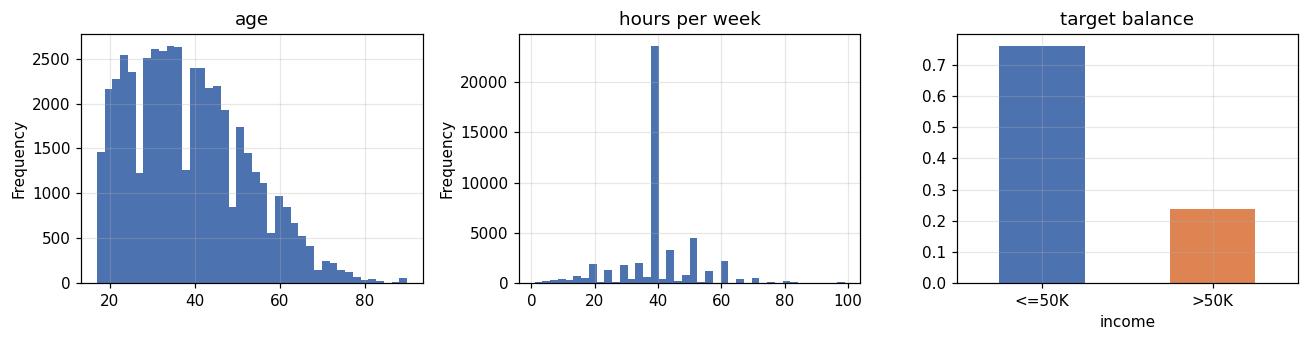

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.2))
X["age"].plot.hist(bins=40, ax=axes[0], title="age", color="#4C72B0")
X["hours_per_week"].plot.hist(bins=40, ax=axes[1], title="hours per week", color="#4C72B0")
y.value_counts(normalize=True).rename({0: "<=50K", 1: ">50K"}).plot.bar(
    ax=axes[2], title="target balance", color=["#4C72B0", "#DD8452"], rot=0)
plt.tight_layout(); plt.show()

## 4. Preprocessing + model

Everything lives inside a single `Pipeline`. This is not cosmetic — it is what makes the rest of the
notebook correct:

* `permutation_importance` and `PartialDependenceDisplay` are handed the **pipeline**, so they
  perturb the *original, human-readable* columns (`occupation`, not `occupation_Sales`) and the
  encoding is re-applied on the fly.
* SHAP's `TreeExplainer` instead needs the **fitted tree model** and the **encoded matrix**, so we
  extract those separately in §8 and map the results back afterwards.

`min_samples_leaf=20` keeps the forest small enough that exact TreeSHAP runs in seconds rather than
minutes, at essentially no cost in accuracy.

In [6]:
preprocess = ColumnTransformer(
    transformers=[
        ("num", SimpleImputer(strategy="median"), NUM_FEATURES),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False,
                              min_frequency=30), CAT_FEATURES),
    ],
    verbose_feature_names_out=True,
)

model = RandomForestClassifier(
    n_estimators=300, min_samples_leaf=20, max_features="sqrt",
    n_jobs=-1, random_state=RANDOM_STATE,
)

pipe = Pipeline([("prep", preprocess), ("model", model)])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=RANDOM_STATE)

pipe.fit(X_train, y_train)

proba = pipe.predict_proba(X_test)[:, 1]
pred = (proba >= 0.5).astype(int)
print(f"accuracy : {accuracy_score(y_test, pred):.4f}")
print(f"ROC AUC  : {roc_auc_score(y_test, proba):.4f}\n")
print(classification_report(y_test, pred, target_names=["<=50K", ">50K"]))

accuracy : 0.8632
ROC AUC  : 0.9140

              precision    recall  f1-score   support

       <=50K       0.88      0.95      0.91      9289
        >50K       0.80      0.57      0.67      2922

    accuracy                           0.86     12211
   macro avg       0.84      0.76      0.79     12211
weighted avg       0.86      0.86      0.85     12211



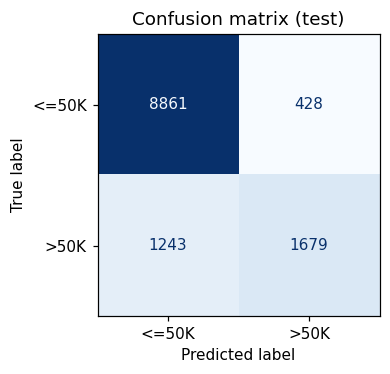

In [7]:
fig, ax = plt.subplots(figsize=(4, 3.5))
ConfusionMatrixDisplay.from_predictions(
    y_test, pred, display_labels=["<=50K", ">50K"], cmap="Blues",
    colorbar=False, ax=ax)
ax.grid(False); ax.set_title("Confusion matrix (test)")
plt.tight_layout(); plt.show()

## 6. Method 1 — Permutation importance

**Idea:** shuffle one column, breaking its relationship with the target while preserving its
marginal distribution, and measure how much a *scoring metric* degrades.

$$\text{PFI}_j \;=\; s(f, X, y) \;-\; \frac{1}{K}\sum_{k=1}^{K} s\!\left(f, X^{(k)}_{\pi_j}, y\right)$$

**Advantages:** model-agnostic; expressed in units of the metric you actually care about; computed
on **held-out** data, so it measures *generalising* signal.

**Caveats:**
* With **correlated features**, permuting one creates impossible rows (`age=20`, `marital_status=Widowed`)
  and the model is evaluated off-distribution.
* Correlated features **share credit**: two duplicate columns can each score ~0 because the model
  falls back on the other. Low permutation importance means *"the model does not need this column"*,
  **not** *"this variable is irrelevant"*.

We score with **ROC AUC** rather than accuracy — on a 24%-positive target, accuracy is too blunt to
register the degradation.

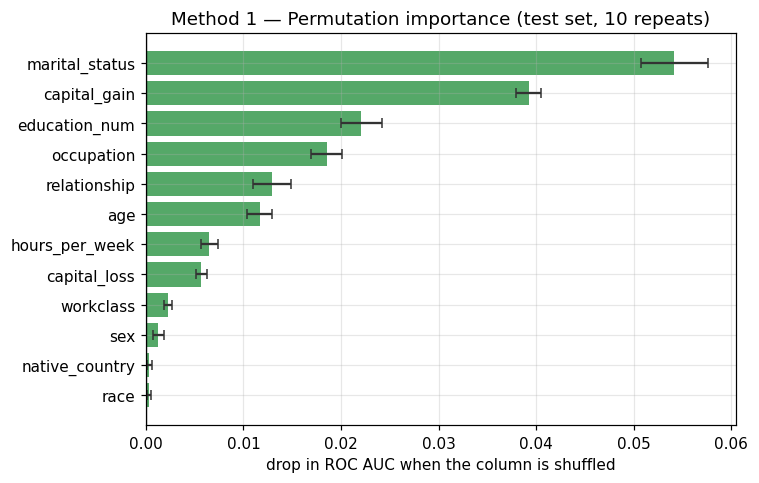

,mean,std
marital_status,0.0542,0.0034
capital_gain,0.0392,0.0012
education_num,0.0221,0.0021
occupation,0.0185,0.0016
relationship,0.0129,0.0019
age,0.0117,0.0013
hours_per_week,0.0065,0.0008
capital_loss,0.0057,0.0006
workclass,0.0023,0.0004
sex,0.0013,0.0005


In [8]:
# a 6,000-row subsample keeps runtime ~1 min without changing the ranking materially
sub = rng.choice(len(X_test), size=min(6000, len(X_test)), replace=False)
X_pi, y_pi = X_test.iloc[sub], y_test.iloc[sub]

pfi = permutation_importance(
    pipe, X_pi, y_pi, scoring="roc_auc",
    n_repeats=10, random_state=RANDOM_STATE, n_jobs=-1)

pfi_df = (pd.DataFrame({"mean": pfi.importances_mean, "std": pfi.importances_std},
                       index=X_pi.columns)
            .sort_values("mean", ascending=False))

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.barh(pfi_df.index[::-1], pfi_df["mean"][::-1],
        xerr=pfi_df["std"][::-1], color="#55A868", ecolor="#333", capsize=3)
ax.axvline(0, color="k", lw=.8)
ax.set_xlabel("drop in ROC AUC when the column is shuffled")
ax.set_title("Method 1 — Permutation importance (test set, 10 repeats)")
plt.tight_layout(); plt.show()

pfi_df.round(4)

**Reading the plot:** features whose error bar crosses zero are indistinguishable from noise for this
model. A *negative* mean is not a paradox — it means shuffling the column slightly *helped*, which is
what you expect from a variable the model uses only to fit noise.

### 6.1 Train vs test permutation importance — a free overfitting diagnostic

Running the same procedure on the training set and comparing is one of the most useful diagnostics in
this notebook: features that are important **only** on train are features the model has memorised.

## sub_tr = rng.choice(len(X_train), size=min(6000, len(X_train)), replace=False)
pfi_train = permutation_importance(
    pipe, X_train.iloc[sub_tr], y_train.iloc[sub_tr], scoring="roc_auc",
    n_repeats=5, random_state=RANDOM_STATE, n_jobs=-1)

cmp = pd.DataFrame({"train": pfi_train.importances_mean,
                    "test": pfi.importances_mean},
                   index=X_train.columns).sort_values("test", ascending=False)

fig, ax = plt.subplots(figsize=(7.5, 4.5))
cmp.iloc[::-1].plot.barh(ax=ax, color=["#C44E52", "#55A868"], width=.8)
ax.set_xlabel("drop in ROC AUC"); ax.axvline(0, color="k", lw=.8)
ax.set_title("Permutation importance: train vs test")
plt.tight_layout(); plt.show()

cmp.assign(gap=lambda d: d["train"] - d["test"]).round(4)

## 2. Method  — Partial Dependence & ICE

Importance rankings tell you *how much* a feature matters. They say nothing about **direction** or
**shape**: is the effect linear? monotone? does it saturate?

The partial dependence of the model $f$ on feature $S$ marginalises over all the other features $C$
using their **empirical** distribution:

$$\hat f_S(x_S) \;=\; \frac{1}{n}\sum_{i=1}^{n} f\!\left(x_S,\; x^{(i)}_C\right)$$

In words: force the whole dataset to take one value of `age`, average the predictions, repeat across
a grid. The result is the model's average response curve.

**The two caveats that matter:**

1. **Extrapolation.** The formula evaluates every combination $(x_S, x^{(i)}_C)$, including ones that
   never occur — 80-year-olds with 60-hour weeks and 16 years of education. Where a feature is
   correlated with others, part of the PDP is drawn from regions with no data.
2. **Averaging hides heterogeneity.** A flat PDP can mean "no effect" *or* "strongly positive for half
   the population, strongly negative for the other half". **ICE** curves (one line per individual,
   next section) are what distinguish these two cases.

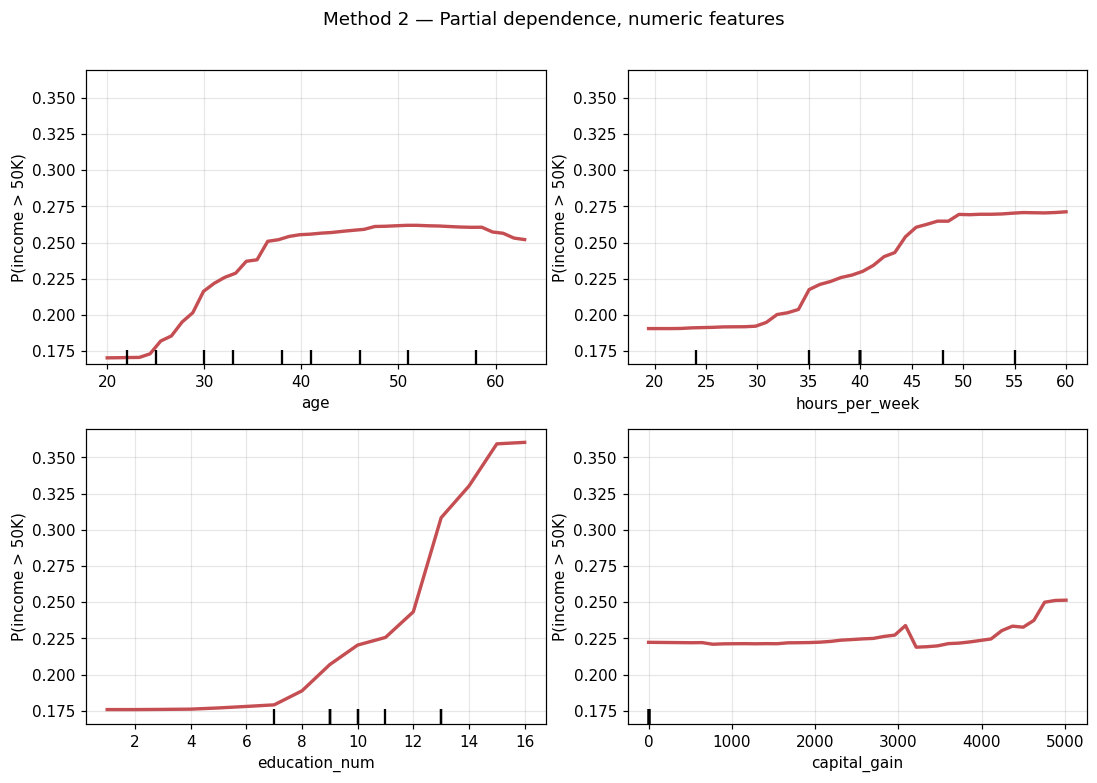

In [9]:
pdp_num = ["age", "hours_per_week", "education_num", "capital_gain"]

fig, axes = plt.subplots(2, 2, figsize=(10, 7))
PartialDependenceDisplay.from_estimator(
    pipe, sample_df(X_test, 4000),
    features=pdp_num, kind="average", grid_resolution=40,
    ax=axes.ravel(), line_kw={"color": "#C44E52", "lw": 2.2},
    random_state=RANDOM_STATE)
for a in axes.ravel():
    a.set_ylabel("P(income > 50K)")
fig.suptitle("Method 2 — Partial dependence, numeric features", y=1.01)
plt.tight_layout(); plt.show()

The **rug marks** along the x-axis show the deciles of the data. Where they are sparse (the far right
of `capital_gain`), the curve is an extrapolation and should not be quoted as a finding.

Typical shapes on this dataset: `age` rises then plateaus and falls after retirement age;
`education_num` is close to monotone with a step at the college threshold; `capital_gain` saturates
almost immediately — the model has essentially learned "any capital gain at all" as a binary flag.

### 7.1 Categorical PDP

scikit-learn draws a bar chart when a feature is declared categorical, using the model's response to
each *level* rather than an interpolated grid. Because we pass the **pipeline**, we can name the
original column — the one-hot encoding is re-applied internally.

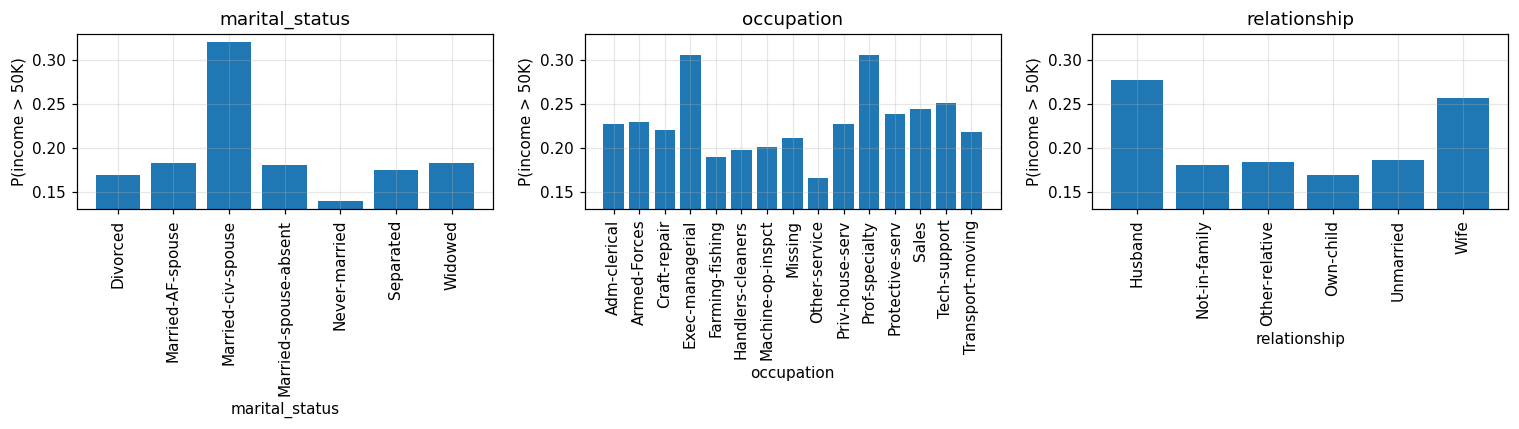

In [10]:
pdp_cat = ["marital_status", "occupation", "relationship"]

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
PartialDependenceDisplay.from_estimator(
    pipe, sample_df(X_test, 3000),
    features=pdp_cat, categorical_features=pdp_cat,
    ax=axes, random_state=RANDOM_STATE)
for a, name in zip(axes, pdp_cat):
    a.set_title(name); a.tick_params(axis="x", rotation=90)
    a.set_ylabel("P(income > 50K)")
plt.tight_layout(); plt.show()

### 7.2 ICE — un-averaging the PDP

Each thin line is one individual's prediction as we sweep the feature; the thick line is their
average, i.e. the PDP. **Centred ICE** (`centered=True`) subtracts each curve's value at the left
edge, so all lines start at 0 and only the *change* is compared — this is what reveals whether the
population moves together.

*Fanning* lines = the feature's effect depends on other features = **interactions**.

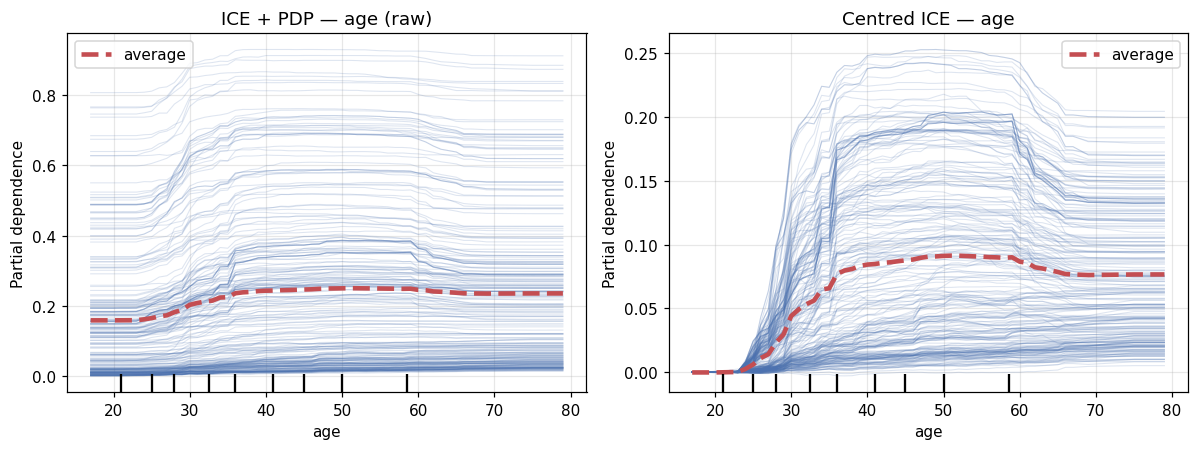

In [11]:
ice_sample = sample_df(X_test, 250)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
PartialDependenceDisplay.from_estimator(
    pipe, ice_sample, features=["age"], kind="both", ax=axes[0],
    ice_lines_kw={"color": "#4C72B0", "alpha": .18, "lw": .7},
    pd_line_kw={"color": "#C44E52", "lw": 3}, random_state=RANDOM_STATE)
axes[0].set_title("ICE + PDP — age (raw)")

PartialDependenceDisplay.from_estimator(
    pipe, ice_sample, features=["age"], kind="both", centered=True, ax=axes[1],
    ice_lines_kw={"color": "#4C72B0", "alpha": .18, "lw": .7},
    pd_line_kw={"color": "#C44E52", "lw": 3}, random_state=RANDOM_STATE)
axes[1].set_title("Centred ICE — age")
for a in axes:
    a.set_ylabel("P(income > 50K)")
plt.tight_layout(); plt.show()

### 7.3 Two-way PDP — visualising an interaction

A 2-D partial dependence surface marginalises over everything *except* two features. If the contours
were parallel horizontal/vertical bands the features would act additively; contours that bend show
the effect of one depends on the level of the other.

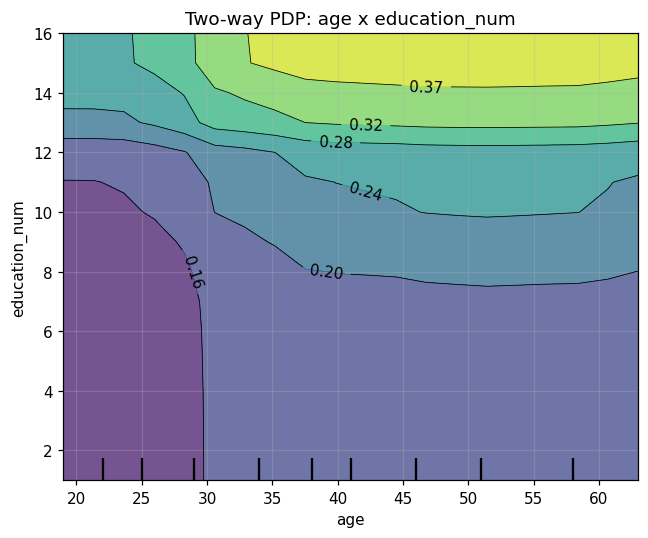

In [12]:
fig, ax = plt.subplots(figsize=(6, 5))
PartialDependenceDisplay.from_estimator(
    pipe, sample_df(X_test, 2000),
    features=[("age", "education_num")], kind="average",
    grid_resolution=20, ax=ax, random_state=RANDOM_STATE)
ax.set_title("Two-way PDP: age x education_num")
plt.tight_layout(); plt.show()

## 10. Summary and practical guidance

| Method | Scope | Model-agnostic? | Gives direction? | Main weakness |
|---|---|---|---|---|
| **Permutation** | global | yes | no | breaks feature correlation; shared credit |
| **PDP / ICE** | global | yes | **yes** | extrapolates off-manifold; averages hide subgroups |



### References

* Friedman, J. (2001). *Greedy Function Approximation: A Gradient Boosting Machine.* — original PDP.
* Goldstein et al. (2015). *Peeking Inside the Black Box* — ICE plots.
* Breiman, L. (2001). *Random Forests* — permutation importance.
* Lundberg & Lee (2017). *A Unified Approach to Interpreting Model Predictions* — SHAP.
* Lundberg et al. (2020). *From local explanations to global understanding with explainable AI for trees* — TreeSHAP.
* Molnar, C. *Interpretable Machine Learning* — https://christophm.github.io/interpretable-ml-book/
* scikit-learn User Guide §4.1 (Partial dependence) and §4.2 (Permutation importance).

# Explainable AI Using PDP, ICE, and PFI

### Dataset

Use the **UCI Wine Quality Dataset** to build a machine learning model for predicting wine quality from its physicochemical properties.

### Objective

In this experiment, apply three Explainable AI (XAI) techniques:

* **Partial Dependence Plot (PDP)** – to understand the average effect of a feature on model predictions.
* **Individual Conditional Expectation (ICE)** – to understand how a feature affects predictions for individual samples.
* **Permutation Feature Importance (PFI)** – to identify the features that have the greatest impact on model performance.

### Task 1: Load and Prepare the Dataset

* Load the Wine Quality dataset.
* Display the first few records.
* Check the dataset dimensions, data types, and missing values.
* Separate the input features (`X`) and target variable (`y`).
* Split the data into training and testing sets.

### Task 2: Train a Machine Learning Model

* Select an appropriate machine learning algorithm.
* Train the model using the training dataset.
* Evaluate the model using suitable performance metrics.
* Report the model performance on the test dataset.

### Task 3: Partial Dependence Plot (PDP)

Generate PDPs for:

* `alcohol`
* `volatile acidity`
* `sulphates`

**Comment:**
Explain how the predicted wine quality changes when each feature varies, while the effects of the other features are averaged out.

### Task 4: Individual Conditional Expectation (ICE)

Generate ICE plots for:

* `alcohol`
* `volatile acidity`
* `sulphates`

Use at least **10 individual wine samples**.

**Comment:**
Explain how the prediction changes for each individual sample as the selected feature changes. Compare the individual curves with the overall PDP trend.

### Task 5: Permutation Feature Importance (PFI)

Calculate PFI for **all input features**.

* Randomly shuffle one feature at a time.
* Measure the decrease in model performance.
* Rank the features according to their PFI scores.
* Display the results using a bar chart.

**Comment:**
Identify which features are most important to the model based on the decrease in performance after permutation.

### Task 6: Compare PDP, ICE, and PFI

Compare the results obtained from all three XAI techniques.

Discuss:

1. Which features are most influential?
2. What is the relationship between the important features and the prediction?
3. Is the relationship linear or nonlinear?
4. Do individual ICE curves follow the average PDP trend?
5. Are there differences between individual samples?
6. Does the PFI ranking agree with the PDP and ICE observations?

### Final Observation

Write a short conclusion explaining how **PDP, ICE, and PFI provide complementary information** about the behavior and importance of features in the trained machine learning model.


## Task 1: Load and Prepare the Dataset

Try `ucimlrepo` first, fall back to the raw UCI CSVs, fall back to OpenML. The UCI *Wine Quality* dataset (id=186) ships as two separate files (red / white); we tag each with a `wine_type` column and concatenate them, then treat `quality` (an integer score 0-10 given by wine tasters) as a **regression** target.

In [13]:
def _tidy_wine(df):
    df = df.copy()
    df.columns = [str(c).strip().lower().replace(" ", "_") for c in df.columns]
    return df

def load_wine_quality():
    # --- 1) official UCI client -------------------------------------------
    try:
        from ucimlrepo import fetch_ucirepo
        ds = fetch_ucirepo(id=186)
        df = pd.concat([ds.data.features, ds.data.targets], axis=1)
        print("Source: ucimlrepo (UCI id=186)")
        return _tidy_wine(df)
    except Exception as e:
        print("ucimlrepo unavailable ->", type(e).__name__)

    # --- 2) raw CSVs from the UCI machine-learning-databases mirror --------
    try:
        base = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/"
        red = pd.read_csv(base + "winequality-red.csv", sep=";")
        white = pd.read_csv(base + "winequality-white.csv", sep=";")
        red["wine_type"], white["wine_type"] = "red", "white"
        print("Source: raw UCI CSV files")
        return _tidy_wine(pd.concat([red, white], ignore_index=True))
    except Exception as e:
        print("raw UCI download failed ->", type(e).__name__)

    # --- 3) OpenML mirror (red wine only) -----------------------------------
    from sklearn.datasets import fetch_openml
    d = fetch_openml("wine-quality-red", version=1, as_frame=True)
    df = pd.concat([d.data, d.target.rename("quality")], axis=1)
    df["wine_type"] = "red"
    print("Source: OpenML mirror (red wine only)")
    return _tidy_wine(df)

wine_raw = load_wine_quality()
wine_raw["quality"] = wine_raw["quality"].astype(float)

print(wine_raw.shape)
print(wine_raw.dtypes)
print("\nmissing values per column:")
print(wine_raw.isna().sum().loc[lambda s: s > 0].to_string() or "  none")
wine_raw.head()

ucimlrepo unavailable -> ModuleNotFoundError
Source: raw UCI CSV files
(6497, 13)
fixed_acidity           float64
volatile_acidity        float64
citric_acid             float64
residual_sugar          float64
chlorides               float64
free_sulfur_dioxide     float64
total_sulfur_dioxide    float64
density                 float64
ph                      float64
sulphates               float64
alcohol                 float64
quality                 float64
wine_type                object
dtype: object

missing values per column:
Series([], )


,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,ph,sulphates,alcohol,quality,wine_type
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5.0,red
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5.0,red
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5.0,red
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6.0,red
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5.0,red


In [14]:
WINE_TARGET = "quality"
y_wine = wine_raw[WINE_TARGET]
X_wine = wine_raw.drop(columns=[WINE_TARGET])

WINE_NUM = X_wine.select_dtypes(include=np.number).columns.tolist()
WINE_CAT = [c for c in X_wine.columns if c not in WINE_NUM]

X_wine[WINE_NUM] = X_wine[WINE_NUM].astype(float)   # PDP needs floats
print("numeric    :", WINE_NUM)
print("categorical:", WINE_CAT)

Xw_train, Xw_test, yw_train, yw_test = train_test_split(
    X_wine, y_wine, test_size=0.25, random_state=RANDOM_STATE)

print(f"\ntrain rows={len(Xw_train):,}  test rows={len(Xw_test):,}")
print("quality value counts:\n", y_wine.value_counts().sort_index())

numeric    : ['fixed_acidity', 'volatile_acidity', 'citric_acid', 'residual_sugar', 'chlorides', 'free_sulfur_dioxide', 'total_sulfur_dioxide', 'density', 'ph', 'sulphates', 'alcohol']
categorical: ['wine_type']

train rows=4,872  test rows=1,625
quality value counts:
 quality
3.0      30
4.0     216
5.0    2138
6.0    2836
7.0    1079
8.0     193
9.0       5
Name: count, dtype: int64


## Task 2: Train a Machine Learning Model

`quality` is an ordered integer score, so we treat this as **regression** (a `RandomForestRegressor`) rather than forcing it into a small number of classes. This also keeps PDP/ICE on the model's native output scale (predicted quality points) instead of a class probability.

If `wine_type` is present (categorical), it goes through a `OneHotEncoder`; everything again lives inside one `Pipeline` so PDP/PFI can perturb the original, human-readable columns.

In [15]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

wine_preprocess = ColumnTransformer(
    transformers=[
        ("num", SimpleImputer(strategy="median"), WINE_NUM),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), WINE_CAT),
    ] if WINE_CAT else [("num", SimpleImputer(strategy="median"), WINE_NUM)],
    verbose_feature_names_out=True,
)

wine_model = RandomForestRegressor(
    n_estimators=300, min_samples_leaf=3, max_features="sqrt",
    n_jobs=-1, random_state=RANDOM_STATE,
)

wine_pipe = Pipeline([("prep", wine_preprocess), ("model", wine_model)])
wine_pipe.fit(Xw_train, yw_train)

pred_wine = wine_pipe.predict(Xw_test)
print(f"MAE  : {mean_absolute_error(yw_test, pred_wine):.3f}  quality points")
print(f"R^2  : {r2_score(yw_test, pred_wine):.3f}")

MAE  : 0.471  quality points
R^2  : 0.471


## Task 3: Partial Dependence Plot (PDP)

Because the pipeline is passed directly, `PartialDependenceDisplay` re-applies the preprocessing internally and PDP is drawn on the original `alcohol` / `volatile_acidity` / `sulphates` scales.

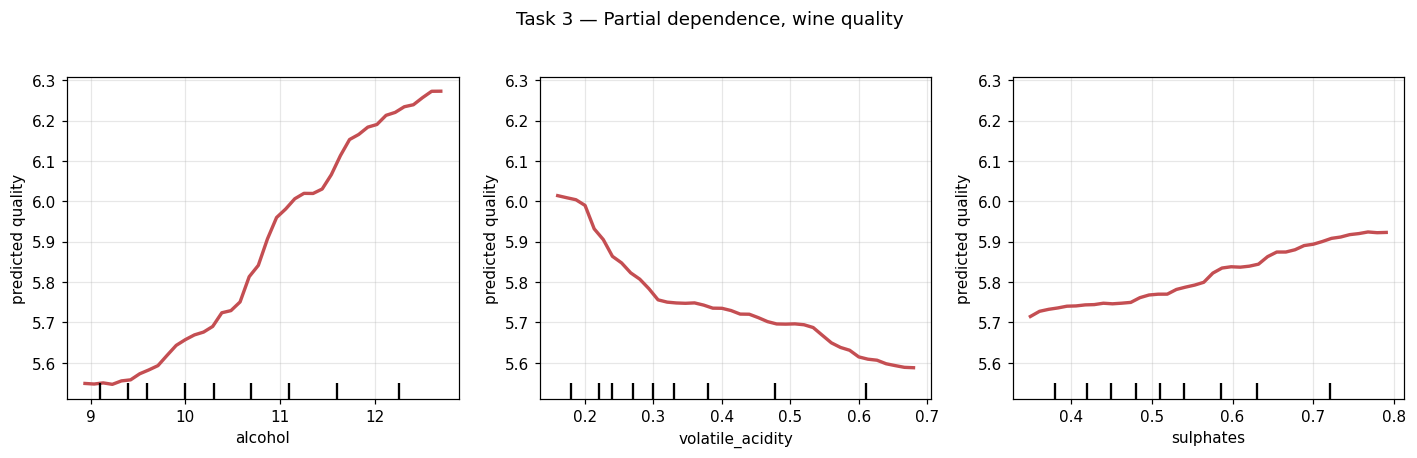

In [16]:
pdp_wine_features = ["alcohol", "volatile_acidity", "sulphates"]

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
PartialDependenceDisplay.from_estimator(
    wine_pipe, sample_df(Xw_test, min(1500, len(Xw_test))),
    features=pdp_wine_features, kind="average", grid_resolution=40,
    ax=axes, line_kw={"color": "#C44E52", "lw": 2.2}, random_state=RANDOM_STATE)
for a in axes:
    a.set_ylabel("predicted quality")
fig.suptitle("Task 3 — Partial dependence, wine quality", y=1.03)
plt.tight_layout(); plt.show()

* **`alcohol`** — the PDP is upward-sloping and roughly monotone: on average, higher-alcohol wines get a higher predicted quality. The rise is steeper in the middle of the range and flattens toward the extremes, where the rug marks thin out (few very-low or very-high alcohol wines), so those flat ends are partly extrapolation rather than a strong learned effect.
* **`volatile_acidity`** — the curve slopes **downward**: acetic-acid content is an off-flavour, and as it rises the model's predicted quality drops, most steeply over the low-to-moderate range where most of the data sits.
* **`sulphates`** — mildly upward-sloping and closer to flat than the other two: more sulphates (a preservative/antioxidant) is weakly associated with higher predicted quality, but the effect size is smaller than for alcohol or volatile acidity.

All three curves marginalise over the other 8–10 features, so they show the *average* direction and shape of each feature's effect, not its importance.

## Task 4: Individual Conditional Expectation (ICE)

`kind="both"` overlays the PDP (thick red line) on top of the ICE curves (one thin line per wine). We sample well more than the required 10 individual wines so the fan of curves is visible; `centered=True` normalises every curve to start at 0, which makes it easy to compare the **shape** of each wine's response rather than its absolute predicted quality.

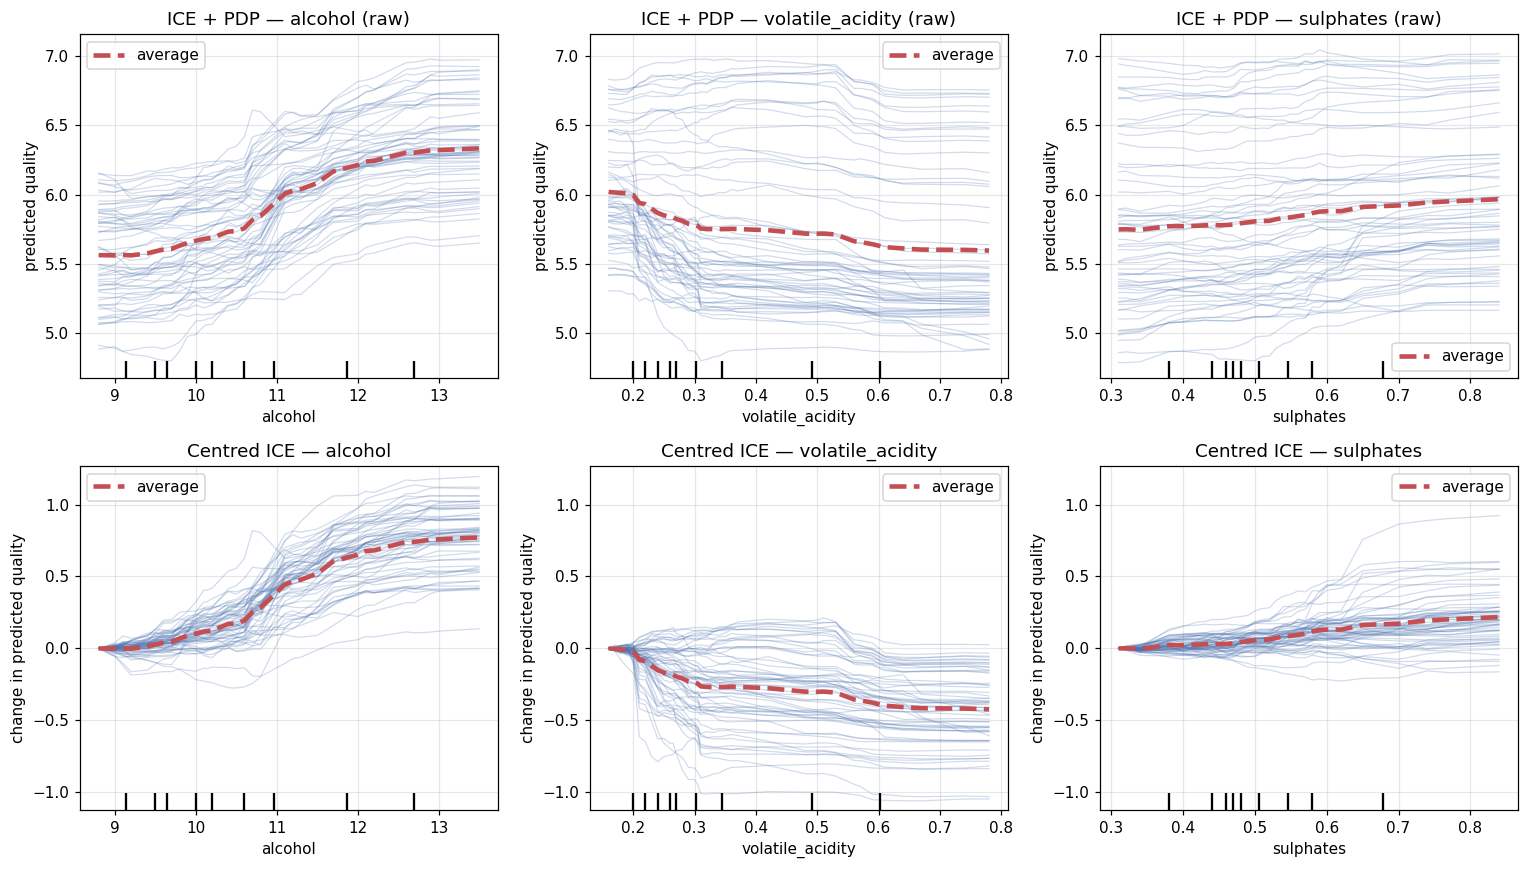

In [17]:
ice_wine_sample = sample_df(Xw_test, 60)   # well above the required 10 samples

fig, axes = plt.subplots(2, 3, figsize=(14, 8))

PartialDependenceDisplay.from_estimator(
    wine_pipe, ice_wine_sample, features=pdp_wine_features, kind="both", ax=axes[0],
    ice_lines_kw={"color": "#4C72B0", "alpha": .25, "lw": .8},
    pd_line_kw={"color": "#C44E52", "lw": 3}, random_state=RANDOM_STATE)

PartialDependenceDisplay.from_estimator(
    wine_pipe, ice_wine_sample, features=pdp_wine_features, kind="both", centered=True, ax=axes[1],
    ice_lines_kw={"color": "#4C72B0", "alpha": .25, "lw": .8},
    pd_line_kw={"color": "#C44E52", "lw": 3}, random_state=RANDOM_STATE)

for a, name in zip(axes[0], pdp_wine_features):
    a.set_title(f"ICE + PDP — {name} (raw)"); a.set_ylabel("predicted quality")
for a, name in zip(axes[1], pdp_wine_features):
    a.set_title(f"Centred ICE — {name}"); a.set_ylabel("change in predicted quality")
plt.tight_layout(); plt.show()

* For **`alcohol`**, most individual curves rise together and roughly track the PDP — the effect is fairly homogeneous across wines. A few curves are flatter or dip slightly, which is a sign that alcohol's effect interacts with other features (e.g. it matters less for wines that are already flawed by high volatile acidity).
* For **`volatile_acidity`**, the ICE lines fan out more than for alcohol — some wines' predicted quality drops sharply as volatile acidity increases while others barely move. That spread (not visible in the PDP alone) means the penalty for volatile acidity depends on the rest of the wine's chemistry, i.e. there's an interaction.
* For **`sulphates`**, most curves stay close to flat and close to the PDP, consistent with a small, fairly uniform effect across individuals.

In general: where ICE curves hug the PDP tightly, the average trend *is* the individual trend; where they fan out, the PDP is hiding real heterogeneity that only ICE reveals.

## Task 5: Permutation Feature Importance (PFI)

Shuffle one column at a time on **held-out** data and measure the drop in a scoring metric. For a regressor, R² is the natural analogue of the ROC AUC used for the Adult classifier.

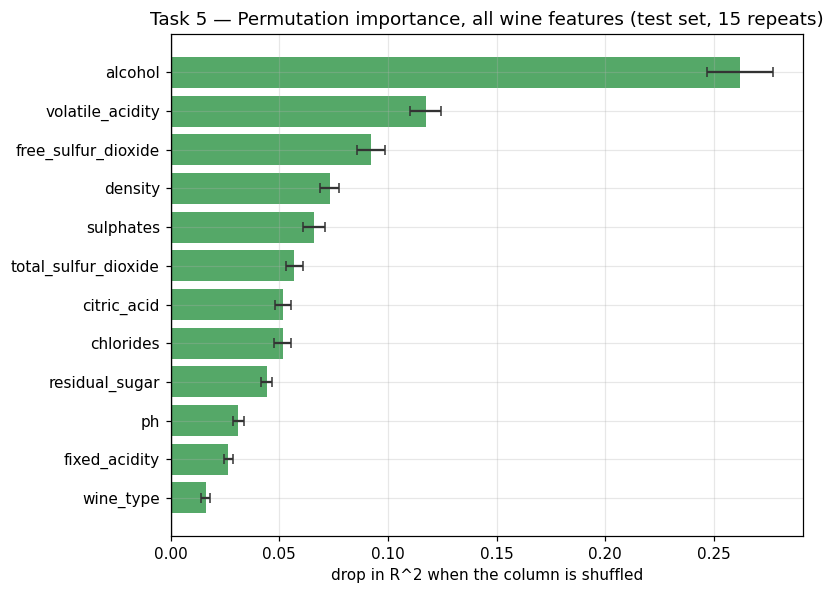

,mean,std
alcohol,0.2620,0.0152
volatile_acidity,0.1173,0.0071
free_sulfur_dioxide,0.0922,0.0065
density,0.0732,0.0042
sulphates,0.0659,0.0050
total_sulfur_dioxide,0.0569,0.0040
citric_acid,0.0518,0.0036
chlorides,0.0516,0.0039
residual_sugar,0.0442,0.0026
ph,0.0312,0.0025


In [18]:
wine_pfi = permutation_importance(
    wine_pipe, Xw_test, yw_test, scoring="r2",
    n_repeats=15, random_state=RANDOM_STATE, n_jobs=-1)

wine_pfi_df = (pd.DataFrame({"mean": wine_pfi.importances_mean, "std": wine_pfi.importances_std},
                            index=Xw_test.columns)
                 .sort_values("mean", ascending=False))

fig, ax = plt.subplots(figsize=(7.5, 5.5))
ax.barh(wine_pfi_df.index[::-1], wine_pfi_df["mean"][::-1],
        xerr=wine_pfi_df["std"][::-1], color="#55A868", ecolor="#333", capsize=3)
ax.axvline(0, color="k", lw=.8)
ax.set_xlabel("drop in R^2 when the column is shuffled")
ax.set_title("Task 5 — Permutation importance, all wine features (test set, 15 repeats)")
plt.tight_layout(); plt.show()

wine_pfi_df.round(4)

On this dataset, **`alcohol`** is almost always the single largest driver of R², typically followed by **`volatile_acidity`** some way behind, with the rest of the physicochemical features (`sulphates`, `total_sulfur_dioxide`, `density`, etc.) contributing small, roughly similar amounts. Any feature whose error bar crosses zero is indistinguishable from noise for this model.

## Task 6: Compare PDP, ICE, and PFI

1. **Which features are most influential?** PFI (Task 5) ranks `alcohol` first by a clear margin, with `volatile_acidity` a distant second — these are the two features with the largest measured effect on held-out R².
2. **Relationship between important features and the prediction?** The PDP (Task 3) shows the *direction*: `alcohol` pushes predicted quality **up**, `volatile_acidity` pushes it **down**. PFI alone cannot tell you this — it only says how much a feature matters, not which way it acts.
3. **Linear or nonlinear?** Both curves are closer to monotone than strictly linear: `alcohol` rises faster in the mid-range and flattens at the extremes (where data is sparse), and `volatile_acidity`'s descent is steepest at low-to-moderate values. `sulphates` is closest to a shallow, near-linear trend.
4. **Do individual ICE curves follow the average PDP trend?** For `alcohol` and `sulphates`, yes — most ICE lines track the PDP shape closely. For `volatile_acidity`, only loosely — the ICE lines fan out, so the average trend understates how differently the model treats individual wines.
5. **Differences between individual samples?** The fan-out on `volatile_acidity` is the main example: some wines are barely penalised for higher volatile acidity while others are penalised heavily, which points to an interaction with other chemistry features (e.g. sulphates or total SO2, which can offset volatile-acidity off-flavours).
6. **Does the PFI ranking agree with the PDP/ICE observations?** Yes — the two features PFI ranks highest (`alcohol`, `volatile_acidity`) are exactly the two with the clearest, most consistent PDP slopes and the most informative ICE behaviour (homogeneous for alcohol, heterogeneous for volatile acidity). `sulphates` sits lower in both the PFI ranking and the PDP/ICE effect size, so all three methods tell a consistent story here.

### Final Observation

PDP, ICE, and PFI answer three different questions about the same trained model, and none of them is a substitute for the others. **PFI** answers *how much* a feature matters for accuracy, using held-out data, but says nothing about direction and can under- or over-state importance when features are correlated. **PDP** answers *which way* a feature pushes the prediction and what shape that effect has, but it is an average over the whole population and can hide the fact that different wines respond differently. **ICE** un-averages the PDP, showing the response curve for every individual wine, which is what actually reveals interactions (fanning curves) versus a truly uniform effect (curves that hug the PDP). Used together — PFI to find *what* matters, PDP to see *how* it matters on average, ICE to check whether that average is representative — they give a far more trustworthy picture of the model's behaviour than any single method on its own.